# Classification of patients and HCs

This notebook classifies SCZ, MDD, and BD against held-out healthy controls using multibin RSI metrics.

In [8]:
from pathlib import Path
import sys

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


project_root = Path('../..').resolve()
info_dir = project_root / 'data' / 'clinical' / 'info'
rsi_dir = project_root / 'results' / 'rsi' / 'clinical'
classification_results_dir = project_root / 'analysis' / 'clinical' / 'results'
font_path = project_root / 'font' / 'Whitney-Medium.otf'

if str(project_root) not in sys.path:
    # Keep installed packages ahead of repository-only analysis helpers.
    sys.path.append(str(project_root))

from analysis.clinical.functions import (
    harmonize_with_combat,
    plot_svm_classification,
    run_svm_classification,
)


if font_path.exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['svg.fonttype'] = 'none' 

## Load multibin RSI and metadata

In [9]:
def format_subject_ids(values):
    """Return numeric subject identifiers as zero-padded strings."""
    return pd.Index([f'{int(value):04d}' for value in values], name='Subject_ID')


def load_metadata(cohort):
    """Load one cohort's metadata and index it by subject identifier."""
    metadata = pd.read_csv(info_dir / f'{cohort}_meta_info.csv')
    metadata.index = format_subject_ids(metadata['sub_uid'])
    if metadata.index.has_duplicates:
        raise ValueError(f'Duplicate subject identifiers in {cohort} metadata')
    return metadata


def load_multibin_rsi(cohort, subject_ids):
    """Load and flatten a subject-by-parcel-by-bin RSI array."""
    multibin_rsi = np.load(rsi_dir / f'{cohort}_multibin_rsi.npy')
    if len(multibin_rsi) != len(subject_ids):
        raise ValueError(
            f'{cohort} RSI rows ({len(multibin_rsi)}) do not match metadata '
            f'rows ({len(subject_ids)})'
        )
    flattened_rsi = multibin_rsi.reshape(len(multibin_rsi), -1)
    return pd.DataFrame(flattened_rsi, index=subject_ids)


def build_confounds(metadata, subject_ids):
    """Encode ComBat and regression covariates in RSI row order."""
    columns = ['diagnosis', 'PatientSex', 'PatientAge', 'site']
    confounds = metadata.loc[subject_ids, columns].copy()
    confounds['PatientSex'] = confounds['PatientSex'].map({'F': 0, 'M': 1})
    confounds['site'] = confounds['site'].map(
        {'PKU3': 0, 'PKU6': 1, 'PKU6-CP': 2}
    )
    if confounds.isna().any().any():
        invalid = confounds.columns[confounds.isna().any()].tolist()
        raise ValueError(f'Unmapped or missing confounds: {invalid}')
    return confounds


hc_test_meta = load_metadata('HC_test')
scz_meta = load_metadata('SCZ')
mdd_meta = load_metadata('MDD')
bd_meta = load_metadata('BD')

hc_test_rsi = load_multibin_rsi('HC_test', hc_test_meta.index)
scz_rsi = load_multibin_rsi('SCZ', scz_meta.index)
mdd_rsi = load_multibin_rsi('MDD', mdd_meta.index)
bd_rsi = load_multibin_rsi('BD', bd_meta.index)

hc_test_confounds = build_confounds(hc_test_meta, hc_test_rsi.index)
scz_confounds = build_confounds(scz_meta, scz_rsi.index)
mdd_confounds = build_confounds(mdd_meta, mdd_rsi.index)
bd_confounds = build_confounds(bd_meta, bd_rsi.index)

print(f'HC: {len(hc_test_rsi)}')
print(f'SCZ: {len(scz_rsi)}')
print(f'MDD: {len(mdd_rsi)}')
print(f'BD: {len(bd_rsi)}')

HC: 236
SCZ: 197
MDD: 320
BD: 83


In [10]:
# Harmonize site effects with ComBat

patient_rsi = pd.concat([scz_rsi, mdd_rsi, bd_rsi], axis=0)
patient_confounds = pd.concat(
    [scz_confounds, mdd_confounds, bd_confounds], axis=0
)
combined_rsi = pd.concat([hc_test_rsi, patient_rsi], axis=0)
combined_confounds = pd.concat(
    [hc_test_confounds, patient_confounds], axis=0
)


combined_rsi = harmonize_with_combat(
    features=combined_rsi,
    covariates=combined_confounds,
    batch_col='site',
    discrete_cols=['PatientSex', 'diagnosis'],
    continuous_cols=['PatientAge'],
)

hc_test_rsi = combined_rsi.loc[hc_test_rsi.index].copy()
scz_rsi = combined_rsi.loc[scz_rsi.index].copy()
mdd_rsi = combined_rsi.loc[mdd_rsi.index].copy()
bd_rsi = combined_rsi.loc[bd_rsi.index].copy()

Creating design matrix..
Standardizing data across features..
Fitting L/S model and finding priors..
Finding parametric adjustments..
Final adjustment of data..


## Nested cross-validation

In [11]:
classification_settings = {
    'n_splits': 10,
    'n_permutations': 5000,
    'n_jobs': 10,
    'result_dir': classification_results_dir,
    'overwrite': True,
}

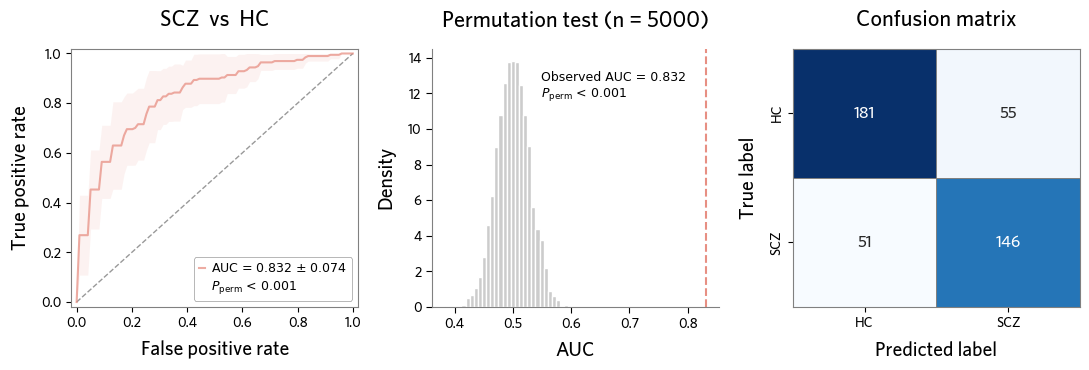

In [13]:
scz_result = run_svm_classification(
    control_features=hc_test_rsi,
    disease_features=scz_rsi,
    control_confounds=hc_test_confounds[['PatientAge', 'PatientSex']],
    disease_confounds=scz_confounds[['PatientAge', 'PatientSex']],
    disease_name='SCZ',
    **classification_settings,
)
plot_svm_classification(scz_result)

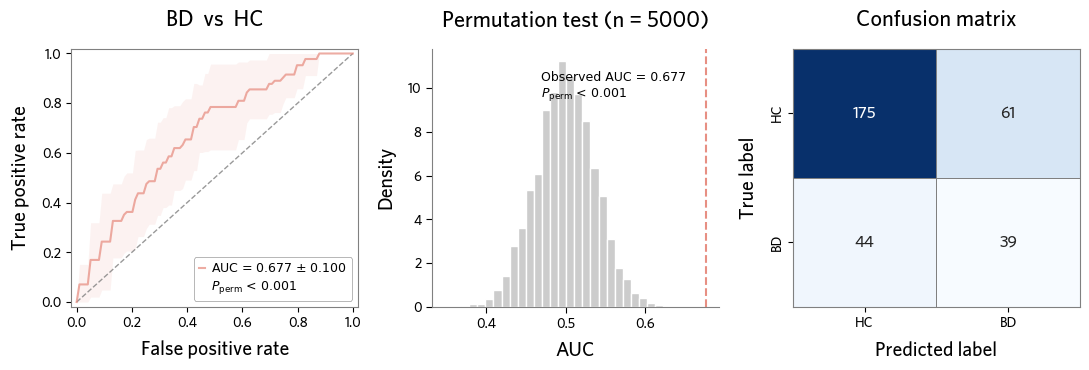

In [6]:
bd_result = run_svm_classification(
    control_features=hc_test_rsi,
    disease_features=bd_rsi,
    control_confounds=hc_test_confounds[['PatientAge', 'PatientSex']],
    disease_confounds=bd_confounds[['PatientAge', 'PatientSex']],
    disease_name='BD',
    **classification_settings,
)
plot_svm_classification(bd_result)

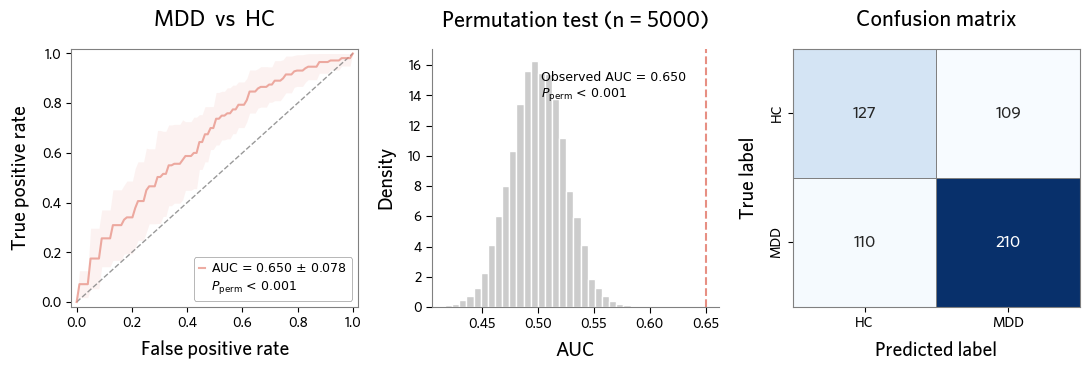

In [7]:
mdd_result = run_svm_classification(
    control_features=hc_test_rsi,
    disease_features=mdd_rsi,
    control_confounds=hc_test_confounds[['PatientAge', 'PatientSex']],
    disease_confounds=mdd_confounds[['PatientAge', 'PatientSex']],
    disease_name='MDD',
    **classification_settings,
)
plot_svm_classification(mdd_result)